# Downstream Exploitation of Space Data
## Session 6: Supervised Machine Learning

### Learning Objectives

You will: 
* know the type of problems supervised machine learning solves and see some examples
* be able to fit a (way too simple) linear regression to a (toy) dataset
* be able to classify objects using a Random Forest classifier
* get familiat with how to analyze the performance of a supervised classifier
* get familiar with variable star classification learning problem

### Regression

Regression is a type of supervised learning in machine learning where the goal is to model the relationship between a dependent variable (target) and one or more independent variables (features). The objective is to predict a continuous outcome based on the input data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression # we will use this to generate a dataset for our regression

In [2]:
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=16)     # fontsize of the axes title
plt.rc('axes',   labelsize=16)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=16)      # legend fontsize
plt.rc('figure', titlesize=16)     # fontsize of the figure title

Let's generate our data:

In [3]:
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

We can get some information on our dataset:

In [4]:
data = pd.DataFrame({'Feature': X.flatten(), 'Target': y})

In [5]:
print('Feature (x):')
print(data['Feature'].describe())
print(' ')
print('Target (y):')
print(data['Target'].describe())

Feature (x):
count    100.000000
mean      -0.103847
std        0.908168
min       -2.619745
25%       -0.600906
50%       -0.126956
75%        0.405952
max        1.852278
Name: Feature, dtype: float64
 
Target (y):
count    100.000000
mean      -3.449530
std       41.321720
min     -118.027454
25%      -30.170786
50%       -0.634702
75%       23.478589
max       89.033145
Name: Target, dtype: float64


We now split our dataset into a train (80%) and test sets (20%):

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Discuss with your neighbour:** why is it important to have a separate test set?

We will now fit a very simple linear regression model to this dataset, i.e. a straight line described as y = mx + b:

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test) # making predictions on the test set

We can now visualize our dataset and the fitted line:

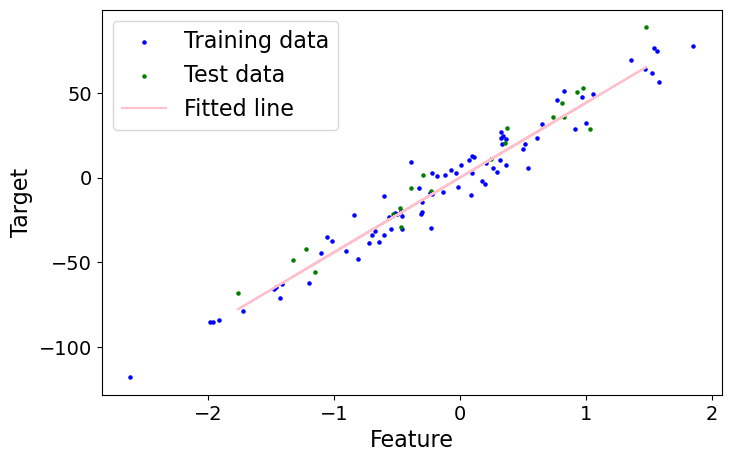

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training data', s=5) # trainin set
plt.scatter(X_test, y_test, color='green', label='Test data', s=5) # test set
plt.plot(X_test, y_pred, color='pink', label='Fitted line') # the line we have fitted
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

Let's print the regression parameters:

In [11]:
print(f'Coefficient: {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')

Coefficient: 44.24418215597419
Intercept: 0.09922221422587807


Therefore, our model is decribed by the following equation:

In [12]:
print(f' y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

 y = 44.24x + 0.10


We can predict the value of the target variable for a new datapoint (not in our dataset) using our model:

In [13]:
new_data = np.array([[3.7]])  # change the number in [] to predit a new y value

predicted_y = model.predict(new_data)
print(f'y({new_data[0][0]}) = {predicted_y[0]}')

y(3.7) = 163.80269619133037


**To do:** Try a few different x values to predict y values for them.

We can evaluate the model by looking at some of its performance metrics:

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Squared Error (MSE): 104.20
R-squared (R²): 0.94


**Discuss with your neighbour:** do you think the model performs well?

**Note:** this is not what you would do for a real-world scientific regression :) You would typically use something more sophisticated, like statsmodels. This is however not a course on linear regression and we are just using this to demonstrate that it is a supervised machine learning task!

### Classification

Classification is a type of supervised learning in machine learning where the goal is to assign a label or category to a given input based on its features. The model is trained on a labeled dataset to predict the label of new, unseen data.

#### Toy dataset

In [16]:
from sklearn.datasets import load_iris # we will use this to get our dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

Let's load our dataset:

In [17]:
iris = load_iris()
X = iris.data  # features (sepal length, sepal width, petal length, petal width)
y = iris.target  # labels (0 = setosa, 1 = versicolor, 2 = virginica)

Let's do some data exploration:

In [18]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [19]:
df.head() # prints the first N rows of the dataset (default = 5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [20]:
df.describe() # summary statistics for each column

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [21]:
df.info() # some useful general info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


We then split the data into a training (80%) and test (20%) set:

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Let's train our classifier:

In [23]:
clf = RandomForestClassifier(n_estimators=5, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=42)

Once it is trained, we predit the label (y) on the test set that we have set aside:

In [24]:
y_pred = clf.predict(X_test)

We can see a classification report to see how our classifier performed:

In [25]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      1.00      0.95         9
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



**Discuss with your neighbour:** what do you think about the performance of this classifier?

It is also very useful to look at the confusion matrix:

In [26]:
cm = confusion_matrix(y_test, y_pred)

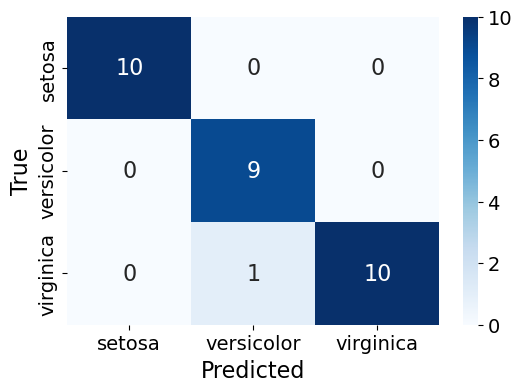

In [30]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**To do:** Change the number of estimators (trees) and see how it changes the classification report and the confusion matrix.

**Discuss with your neighbour:** What can you conclude from this? 

We can also see how important the features are:

In [28]:
importances = clf.feature_importances_
feature_names = iris.feature_names

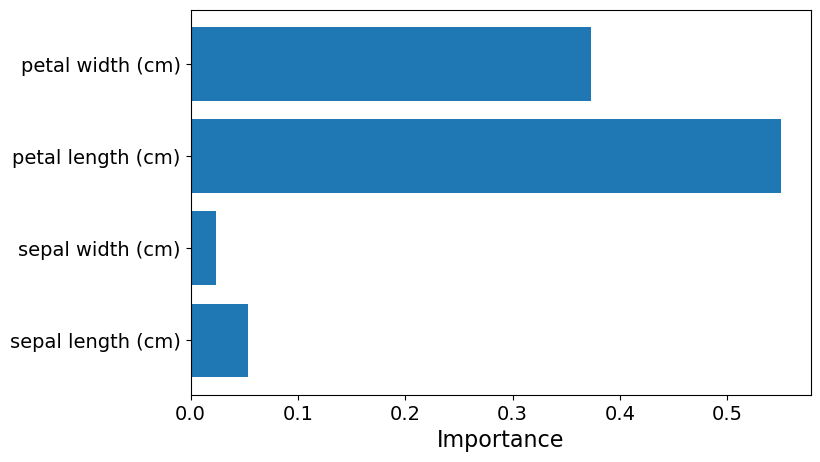

In [31]:
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.show()

**Discuss with your neighbour:** What conclusion can you make from the feature importance? In your opinion, would the classifier have performed the same if certain features were removed?

#### Variable star dataset

##### Helper functions

Let's first define some functions that will be useful for us:

In [32]:
from scipy.ndimage import gaussian_filter1d

import lightkurve as lk
from astropy.timeseries import LombScargle

In [33]:
def smooth_time_series(time_series, sigma):
    '''
    This function applies Gaussian smoothing to a time series.
    Input: time_series (a series of data points in time order), sigma (width of the filter).
    Output: smoothed time series.
    '''
    smoothed_series = gaussian_filter1d(time_series, sigma=sigma, mode='nearest')
    
    return smoothed_series

In [34]:
def get_random_row(df):
    '''
    This gets a random row from a dataframe and returns TIC, Sector, and Class column content.
    Input: df (dataframe with extracted features).
    Output: TIC (TESS id of a star), Sector (TESS sector), Class (label).
    '''
    random_row = df.sample(n=1).iloc[0]

    return random_row['TIC'], random_row['Sector'], random_row['Class']

In [35]:
def extract_light_curve(tic_id, sector, science_product='QLP'):
    '''
    This function extracts a QLP light curve from a specific sector.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline).
    Output: a search result containing a light curve.
    '''
    search = lk.search_lightcurve(f'TIC {tic_id}', author=science_product)
    light_curve = search[search.mission == f'TESS Sector {sector}']

    return light_curve

In [149]:
def preprocess_light_curve(tic_id, sector, science_product='QLP', sigma=61):
    '''
    This function preprocesses light curve to improve the quality of the data.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline), sigma (width of the filter).
    Output: time and flux after applying TESS quality flags, removing outliers, and smoothing with a Gaussian filter.
    '''
    lc = extract_light_curve(tic_id, sector, science_product=science_product)
    
    if lc is None or len(lc) == 0:
        print(f'No light curve available for TIC {tic_id} in sector {sector}.')
        return None, None 

    light_curve = lc[0].download()
    
    if light_curve is None:
        print(f'Query failed for TIC {tic_id}, sector {sector}.')
        return None, None

    time = light_curve['time'].value
    flux = light_curve['sap_flux'].value

    # step one: applying TESS quality flags -> low-quality data points are removed
    quality_mask = light_curve.quality
    good_quality_mask = (quality_mask == 0)
    
    time = time[good_quality_mask]
    flux = flux[good_quality_mask]

    # step two: removing outliers
    flux_mean = np.mean(flux)
    flux_std = np.std(flux)
    
    time_no_outl = time[np.abs(flux - flux_mean) < 10 * flux_std]
    flux_no_outl = flux[np.abs(flux - flux_mean) < 10 * flux_std]

    # step three: subtracting a Gaussian smoothed time series to remove long-period instrumental trends
    smoothed = smooth_time_series(flux_no_outl, sigma=sigma)
    smoothed_flux = flux_no_outl[:len(smoothed)] - smoothed 
    smoothed_time = time_no_outl[:len(smoothed_flux)]

    smoothed_flux += np.mean(flux_no_outl)

    return smoothed_time, smoothed_flux

In [57]:
def plot_light_curve(tic_id, sector, science_product='QLP', sigma=61):
    '''
    This function plots a preprocessed light curve.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline), sigma (width of the filter).
    Output: none (this function is a process, does not return anything).
    '''
    time, flux = preprocess_light_curve(tic_id, sector, science_product=science_product, sigma=sigma)

    fig, ax = plt.subplots(figsize=(18, 4))
    
    ax.scatter(time, flux, color='black', s=2)
    ax.set_xlabel('Time [d]')
    ax.set_ylabel('Normalized Flux')
    ax.legend(fontsize=12, loc='best') 

    fig.suptitle(f'TIC {tic_id}, sector {sector}')
    
    plt.tight_layout()
    plt.show()

In [150]:
def compute_periodogram(tic_id, sector, science_product='QLP', sigma=61):
    '''
    This function computes a Lomb-Scargle periodogram for a light curve.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline), sigma (width of the filter).
    Output: frequency and power from the Lomb-Scargle periodogram.
    '''
    smoothed_time, smoothed_flux = preprocess_light_curve(
        tic_id, sector, science_product=science_product, sigma=sigma
    )

    cadence = np.diff(smoothed_time)
    sampling = 1 / np.median(cadence)
    nyquist = sampling / 2

    frequency, power = LombScargle(smoothed_time, smoothed_flux).autopower(
        minimum_frequency=0.001,
        maximum_frequency=nyquist,
        normalization='standard'
    )

    return frequency, power

In [151]:
def plot_periodogram(tic_id, sector, science_product='QLP', sigma=61, features=None):
    '''
    This function plots a periodogram with (optionally) extracted frequencies.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline), sigma (width of the filter),
        features (dataframe with extracted features).
    Output: none (this function is a process, does not return anything).
    '''
    frequency, power = compute_periodogram(
        tic_id, sector, science_product=science_product, sigma=sigma
    )

    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(frequency, power, color='blue')

    ax.set_xlabel('Frequency [1/d]')
    ax.set_ylabel('Power')

    if features is not None and not features.empty:
        p = 0
        g = 0

        filtered_row = features[(features["TIC"] == tic_id) & (features["Sector"] == sector)]

        if not filtered_row.empty:
            periods = filtered_row[['PeriodLS', 'PeriodLS2', 'PeriodLS3']].values.flatten().tolist()
        else:
            periods = []

        for period in periods:
            if period is not None and np.isfinite(period) and period > 0:
                freq_val = 1 / period
                if period <= 0.2:
                    if p == 0:
                        ax.axvline(
                            x=freq_val, linestyle='--', color='green', alpha=0.3)
                    else:
                        ax.axvline(x=freq_val, linestyle='--', color='green', alpha=0.3)
                    p += 1
                else:
                    if g == 0:
                        ax.axvline(
                            x=freq_val, linestyle='--', color='purple', alpha=0.3)
                    else:
                        ax.axvline(x=freq_val, linestyle='--', color='purple', alpha=0.3)
                    g += 1

    fig.suptitle(f'TIC {tic_id}, sector {sector}')
    ax.set_xlim(0, 70)
    
    plt.tight_layout()
    plt.show()

In [152]:
def plot_lc_and_pd(tic_id, sector, science_product='QLP', sigma=61, zoom=False):
    '''
    This function plots a light curve, a periodogram, and (optionally) a zoomed-in periodogram on low-frequency regime.
    Input: tic_id (TESS id of a star), sector (TESS sector), science_product (light curve pipeline), sigma (width of the filter),
        zoom (True -> plot zoomed-in version, False -> do not plot).
    Output: none (this function is a process, does not return anything).

    Note that this function will only mark the dominant variability instead of 3 extracted peaks from the dataframe.
    '''
    smoothed_time, smoothed_flux = preprocess_light_curve(
        tic_id, sector, science_product=science_product, sigma=sigma
    )
    frequency, power = compute_periodogram(
        tic_id, sector, science_product=science_product, sigma=sigma
    )

    max_frequency = frequency[np.argmax(power)]

    if zoom:
        fig, axs = plt.subplots(3, 1, figsize=(18, 12))
    else:
        fig, axs = plt.subplots(2, 1, figsize=(18, 8))

    axs[0].scatter(smoothed_time, smoothed_flux, color='black', s=2)
    axs[0].set_xlabel('Time [d]')
    axs[0].set_ylabel('Normalized Flux')
    axs[0].set_title(f'TIC {tic_id}, sector {sector}')

    axs[1].plot(frequency, power, color='blue')
    axs[1].set_xlabel('Frequency [1/d]')
    axs[1].set_ylabel('Power')
    axs[1].set_title(f'f1: {max_frequency:.4f} | p1: {1 / max_frequency:.4f}')
    axs[1].axvline(x=max_frequency, linestyle='--', color='orange', alpha=0.5)
    axs[1].set_xlim(0, 70)

    if zoom:
        axs[2].plot(frequency, power, color='blue')
        axs[2].set_xlabel('Frequency [1/d]')
        axs[2].set_ylabel('Power')
        axs[2].set_title('Periodogram (zoomed)')
        axs[2].axvline(x=max_frequency, linestyle='--', color='orange', alpha=0.5)
        axs[2].set_xlim(0, 5)

    plt.tight_layout()
    plt.show()

##### Exploring the dataset

In [153]:
df = pd.read_csv('supervised.csv').drop(['Unnamed: 0'], axis = 1)
df.head()

,TIC,Sector,Class,Amplitude,AndersonDarling,Autocor_length,Con,Eta_e,FluxPercentileRatioMid20,FluxPercentileRatioMid35,...,Psi_CS,Psi_eta,Q31,Rcs,Skew,SmallKurtosis,Std,StructureFunction_index_21,StructureFunction_index_31,StructureFunction_index_32
0,121788685,40,gdor_spb,0.012499,1.000000,12.0,0.003059,0.049083,0.241412,0.412218,...,0.210949,0.308100,0.012968,0.025453,0.253529,-1.105627,0.007477,1.805659,2.404854,1.358320
1,159107517,40,contact_rot,0.001117,0.972301,12.0,0.007137,0.659307,0.148367,0.271313,...,0.098484,1.898308,0.000744,0.042147,-0.096938,0.355266,0.000567,2.072192,3.199932,1.570209
2,164409716,40,dsct_bcep,0.010492,0.846461,1.0,0.000255,2.111645,0.160205,0.283862,...,0.048566,1.907580,0.007418,0.017033,0.048196,0.076288,0.005468,2.016101,3.074184,1.598993
3,273043307,41,eclipse,0.273848,1.000000,22.0,0.052919,0.010379,0.017463,0.046159,...,0.270511,1.489218,0.037857,0.039258,-3.038883,9.956646,0.109472,2.112600,3.311446,1.598922
4,159716883,40,gdor_spb,0.009554,1.000000,17.0,0.011726,0.636592,0.140787,0.268765,...,0.126239,1.904594,0.006247,0.029084,-0.113706,1.063223,0.004870,1.962611,2.935181,1.530732


In [154]:
df.describe()

,TIC,Sector,Amplitude,AndersonDarling,Autocor_length,Con,Eta_e,FluxPercentileRatioMid20,FluxPercentileRatioMid35,FluxPercentileRatioMid50,...,Psi_CS,Psi_eta,Q31,Rcs,Skew,SmallKurtosis,Std,StructureFunction_index_21,StructureFunction_index_31,StructureFunction_index_32
count,2.130000e+03,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,...,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000,2130.000000
mean,1.898953e+08,40.806573,0.028074,0.906019,7.955399,0.009234,0.953160,0.154091,0.274296,0.403996,...,0.131260,1.374232,0.018116,0.027351,-0.488678,5.575628,0.015116,1.947431,2.873656,1.534299
std,9.953047e+07,2.665323,0.062213,0.193612,9.727300,0.015903,0.685489,0.047483,0.079443,0.105870,...,0.073203,0.661662,0.050463,0.015408,1.768597,61.076739,0.034539,0.247013,0.608900,0.119112
min,2.641282e+07,40.000000,0.000421,0.127973,1.000000,0.000000,0.005116,0.004123,0.008012,0.016949,...,0.017453,0.010080,0.000255,0.004592,-43.827396,-1.506910,0.000213,0.512414,-0.240181,1.027073
25%,1.226842e+08,40.000000,0.003648,0.939672,1.000000,0.000273,0.233453,0.144809,0.262550,0.392930,...,0.072391,0.945883,0.002509,0.017111,-0.218153,-0.165516,0.001890,1.813832,2.529555,1.459856
50%,1.647233e+08,40.000000,0.008258,1.000000,3.000000,0.001637,0.953835,0.153529,0.275214,0.409178,...,0.114601,1.648191,0.005479,0.023915,-0.008731,0.112815,0.004297,1.929980,2.835742,1.538230
75%,2.714342e+08,41.000000,0.018989,1.000000,12.000000,0.009432,1.562788,0.162244,0.287990,0.426088,...,0.178184,1.924458,0.011365,0.032808,0.062463,0.958354,0.010132,2.065988,3.179039,1.593396
max,4.248679e+08,56.000000,1.186902,1.000000,85.000000,0.088404,3.737107,0.354809,0.571573,0.751790,...,0.384733,2.253992,1.167096,0.150166,28.409141,2371.950397,0.720443,3.625031,7.342361,2.306656


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   TIC                              2130 non-null   int64  
 1   Sector                           2130 non-null   int64  
 2   Class                            2130 non-null   object 
 3   Amplitude                        2130 non-null   float64
 4   AndersonDarling                  2130 non-null   float64
 5   Autocor_length                   2130 non-null   float64
 6   Con                              2130 non-null   float64
 7   Eta_e                            2130 non-null   float64
 8   FluxPercentileRatioMid20         2130 non-null   float64
 9   FluxPercentileRatioMid35         2130 non-null   float64
 10  FluxPercentileRatioMid50         2130 non-null   float64
 11  FluxPercentileRatioMid65         2130 non-null   float64
 12  FluxPercentileRatioM

Let's get a random row from the dataframe:

In [156]:
tic, sector, label = get_random_row(df)

In [157]:
tic, sector, label

(270854940, 40, 'contact_rot')

With that we can now take a look at the light curve of this object:

/var/folders/_t/f3t6bcg12r5d8mdzht1w3d9rdpkh79/T/ipykernel_17765/3333291418.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='best')


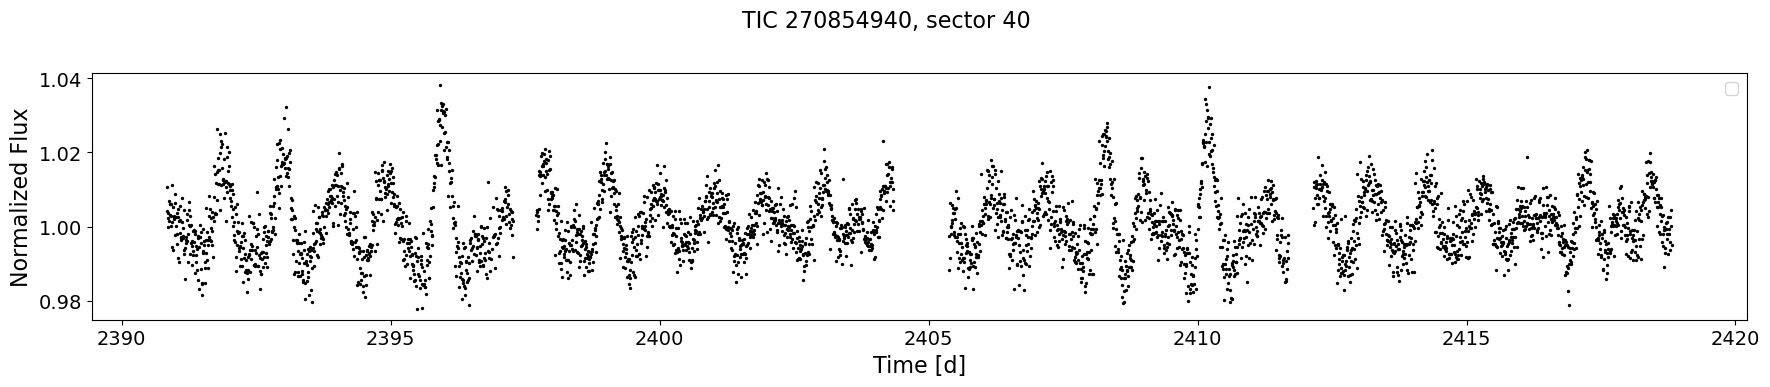

In [158]:
plot_light_curve(tic, sector)

We can of course also use this function for a non-random object if we specify the TIC and Sector manually:

/var/folders/_t/f3t6bcg12r5d8mdzht1w3d9rdpkh79/T/ipykernel_17765/3333291418.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='best')


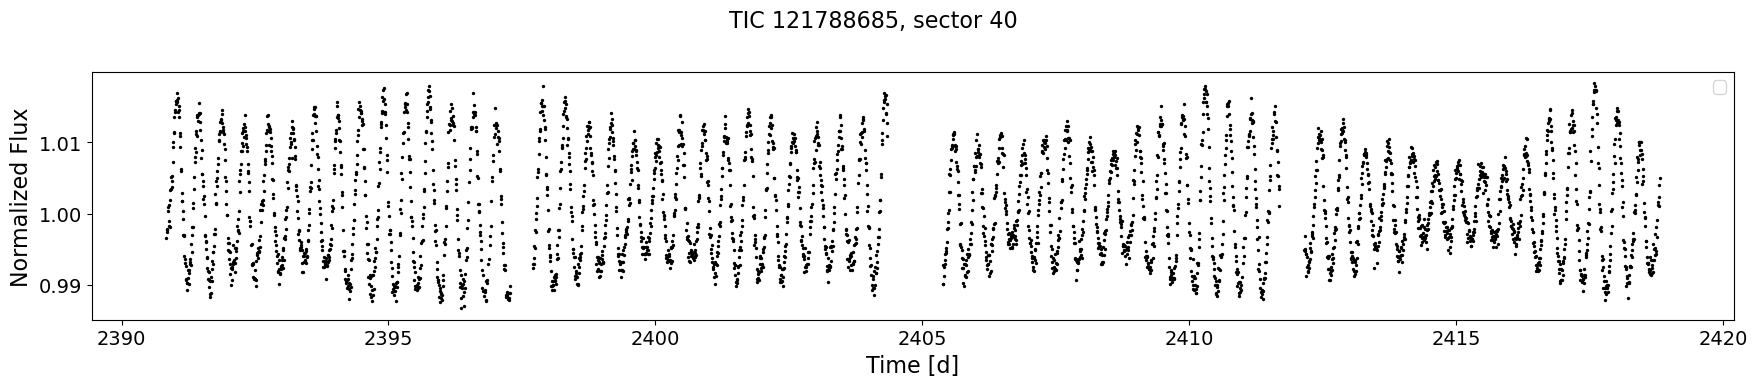

In [159]:
plot_light_curve(121788685, 40)

The Fourier transformation of our random object looks like this:

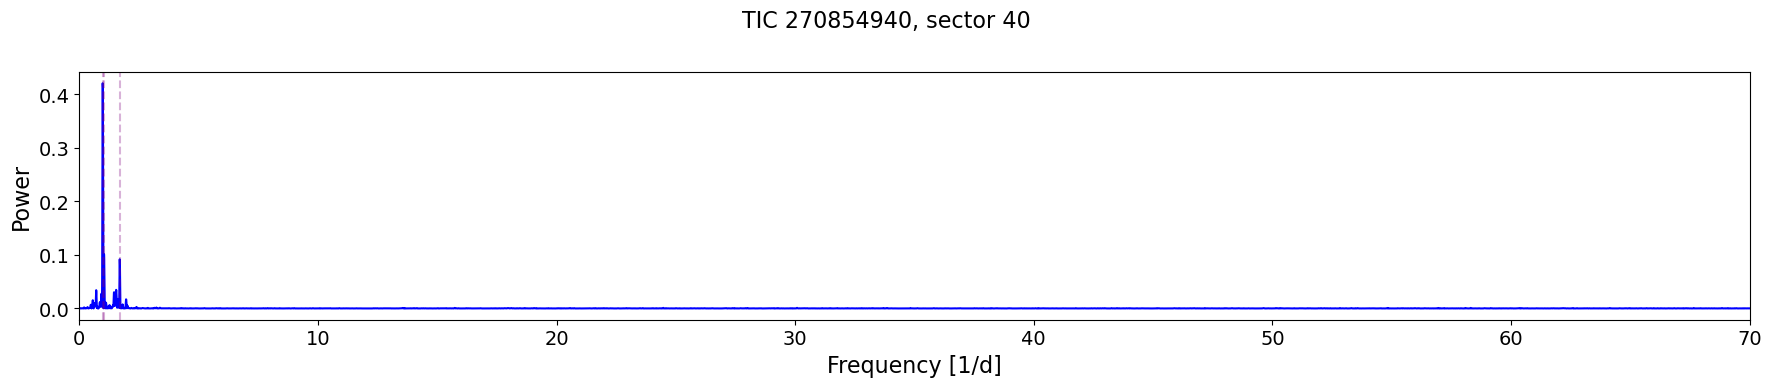

In [160]:
plot_periodogram(tic, sector, features=df) # remove features=df if you don't want to see extracted periods

If you want to look at both the light curve and periodogram, you can do it like this:

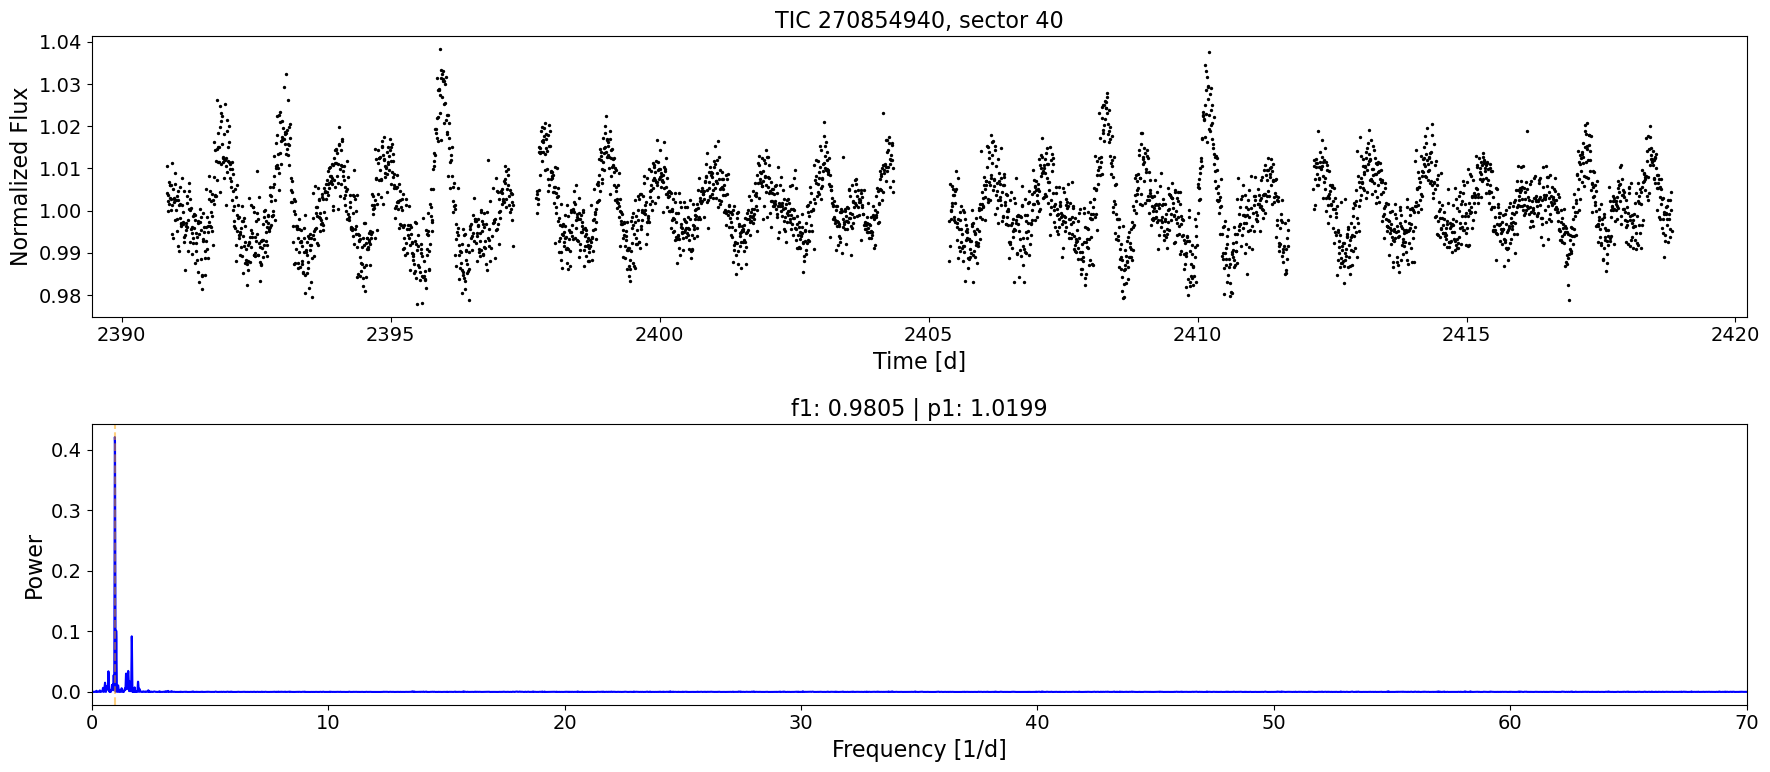

In [161]:
plot_lc_and_pd(tic, sector)

It is also possible to zoom in on the low frequency regime - this is very useful for some classes but not so much for others:

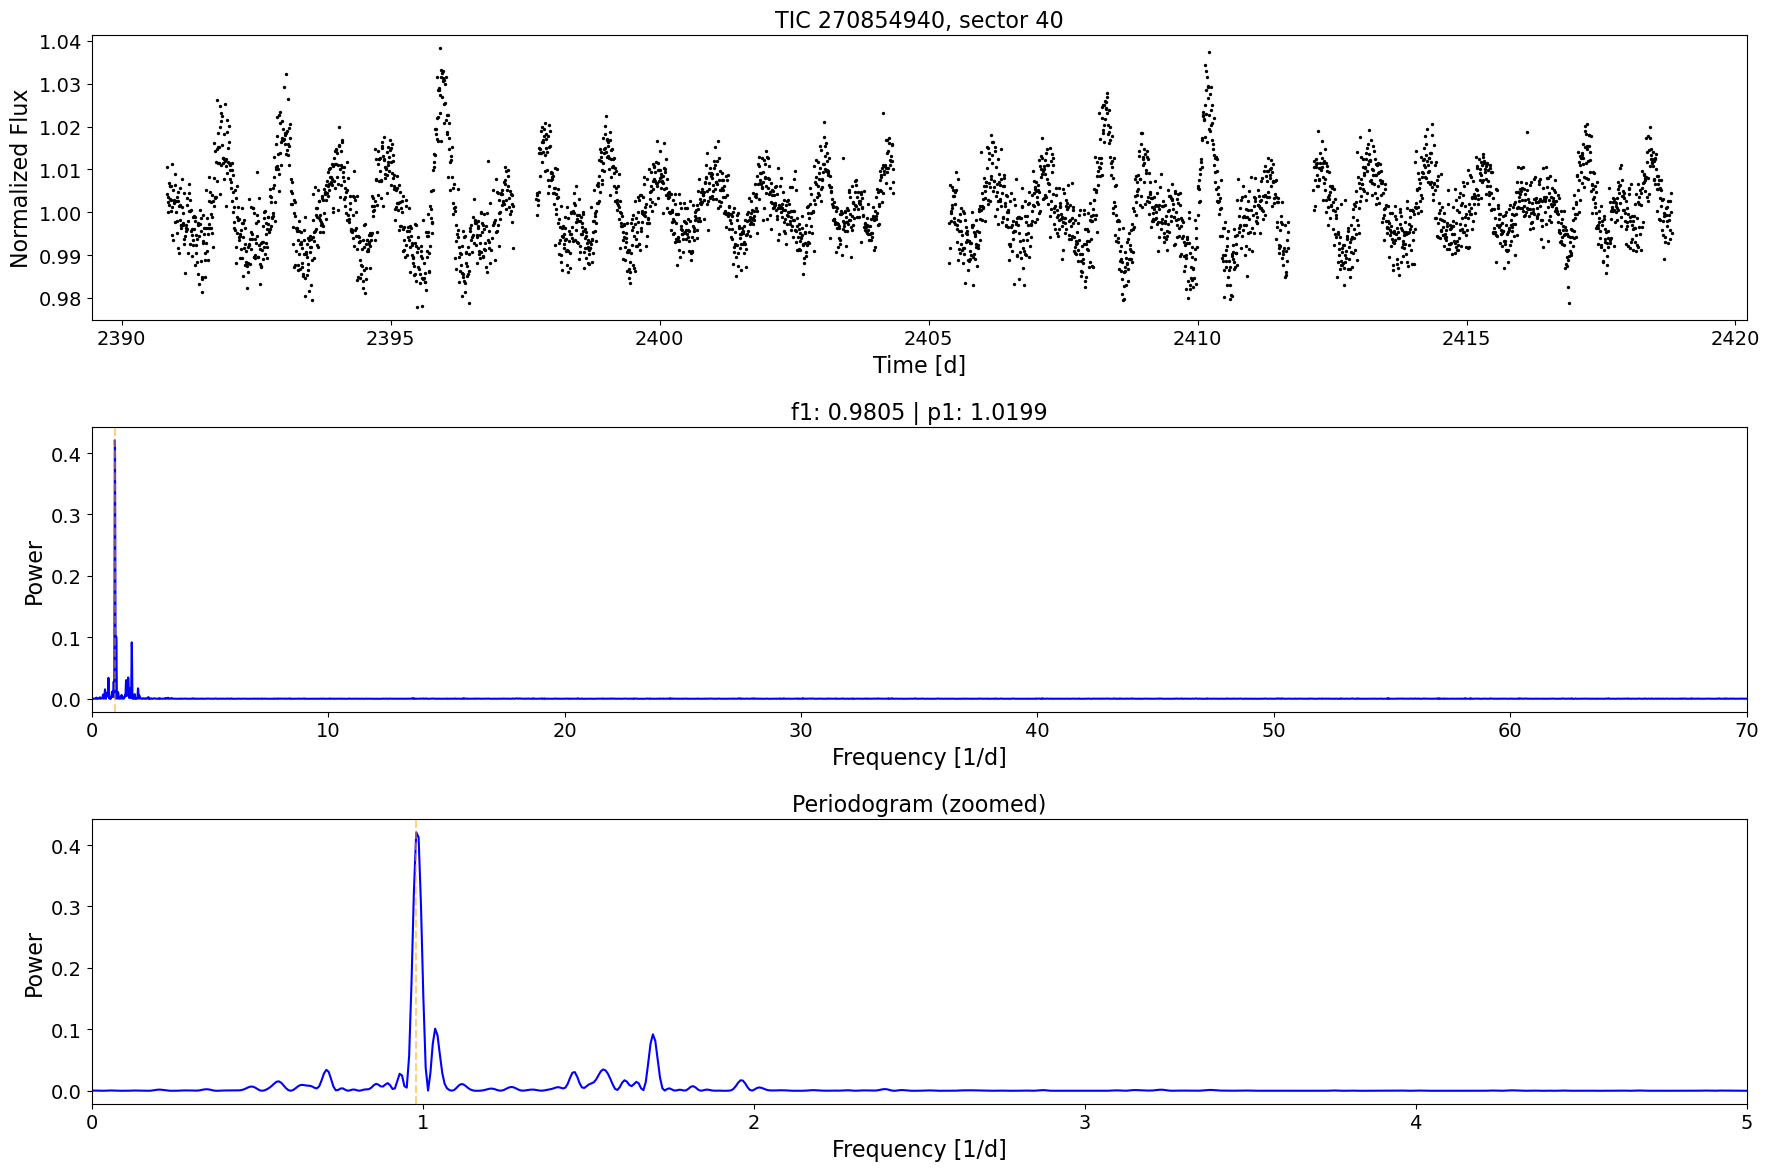

In [162]:
plot_lc_and_pd(tic, sector, zoom=True)

**To do:** Try running these cells with with different random objects a few times so look at different stars.

**Discuss with your neighbour:** Have you noticed for which classes the zoom-in is more useful?

##### Classification

Let's classify our dataset with a RF classifier:

In [163]:
X = df.drop(columns=['TIC', 'Sector', 'Class'])
y = df['Class']

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [165]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [166]:
y_pred = clf.predict(X_test)

In [167]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 contact_rot       0.70      0.83      0.76       119
   dsct_bcep       0.95      0.94      0.94        96
     eclipse       0.94      0.87      0.90        67
    gdor_spb       0.83      0.66      0.74        74
  rrlyr_ceph       0.67      0.50      0.57         4
   solarlike       0.83      0.83      0.83        66

    accuracy                           0.83       426
   macro avg       0.82      0.77      0.79       426
weighted avg       0.84      0.83      0.83       426



In [168]:
cm = confusion_matrix(y_test, y_pred)

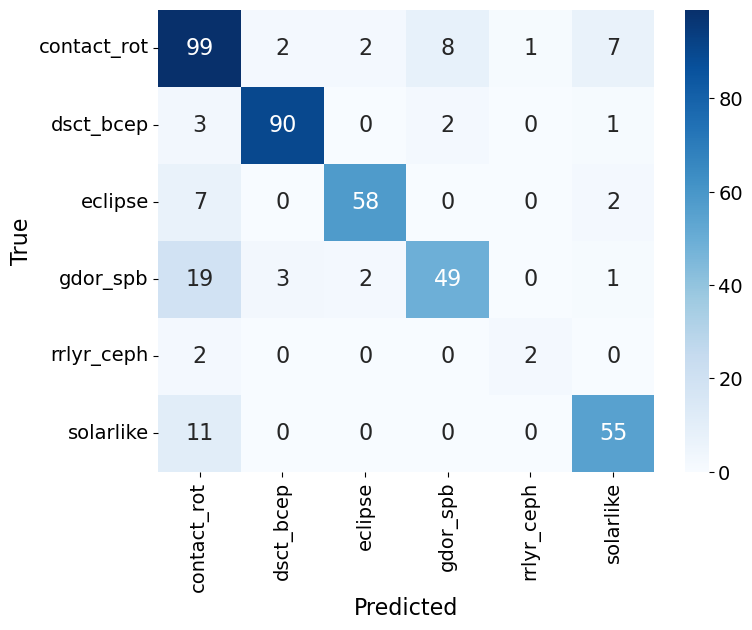

In [169]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This might be a bit difficult to interpret since we have different number of objects in our classes. Let's look at the normalized version of the confusion matrix:

In [170]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

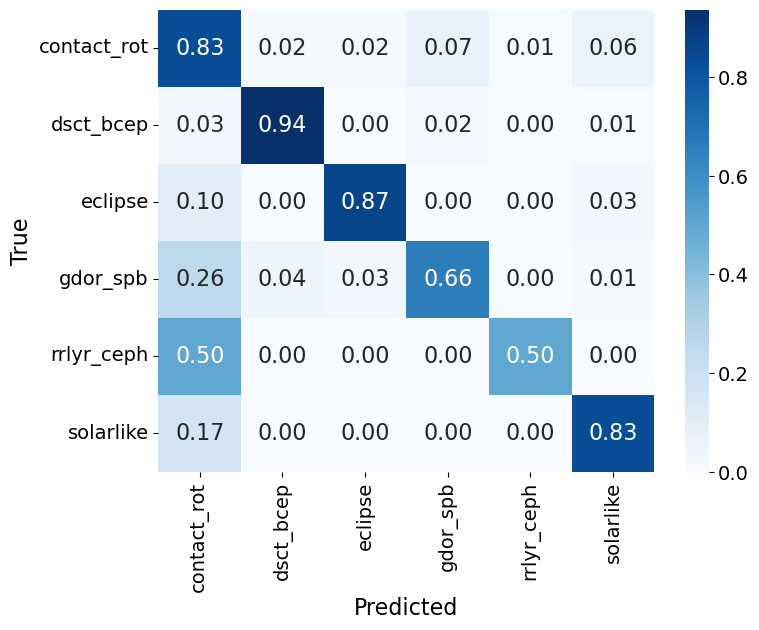

In [171]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
# plt.savefig('confusion_matrix.pdf')
plt.show()

**Put in the report:** This confusion matrix.

**Discuss with your neighbour (put in the report):** Why do you think rrlyr_cepheid class is not retrieved well?

**Discuss with your neighbour (put in the report):** Which other two classes, other than with rrlyd_cepheid (!), are most-heavily confused?

In [172]:
importances = clf.feature_importances_
feature_names = X.columns

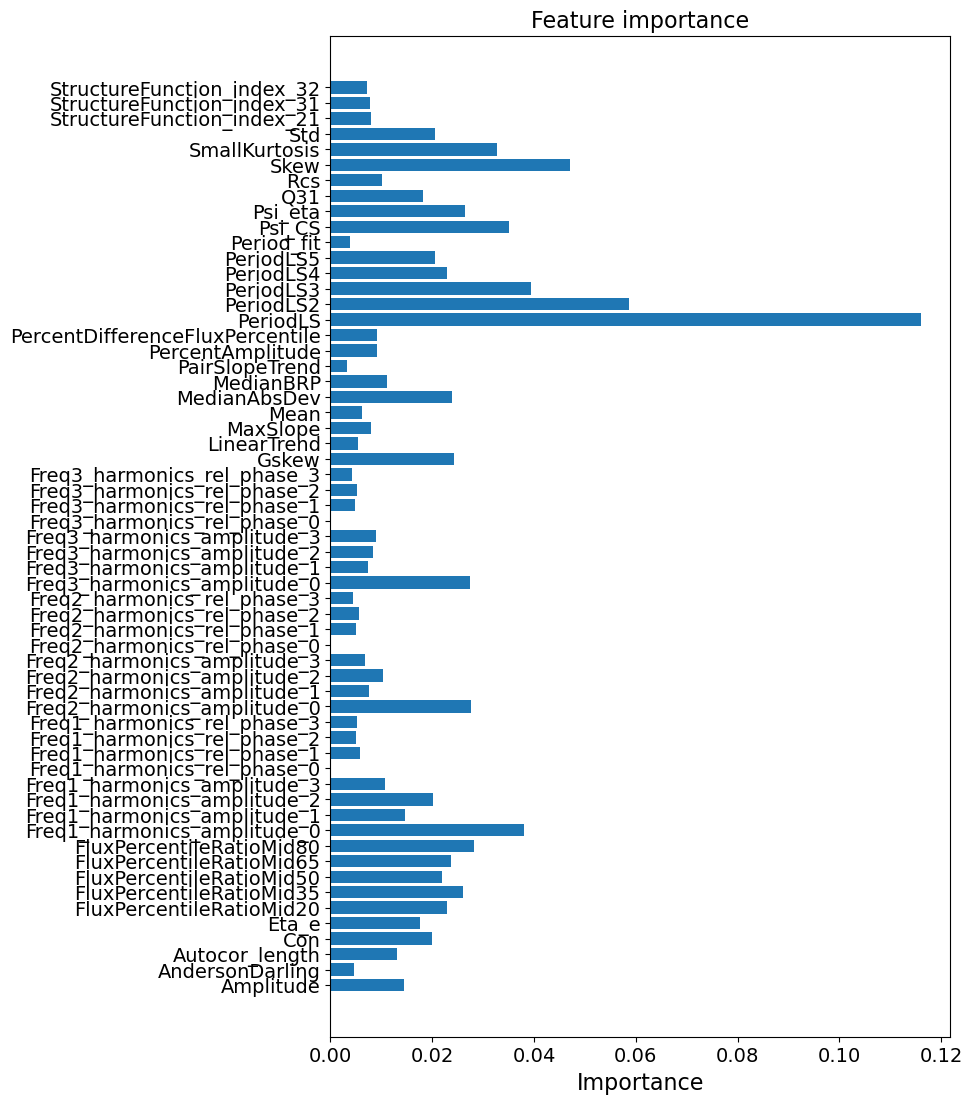

In [173]:
plt.figure(figsize=(8, 13))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Feature importance')
plt.show()

**Discuss with your neighbour:** What are the most important features? Do you think it makes sense given that it is a dataset of variable stars? The description of features here can help you answer this question: https://feets.readthedocs.io/en/latest/tutorial.html#The-Features

**Discuss with your neighbour:** What do you think about the performance of the classifier as a whole?

**To do for the report:** Plot the distribution of PeriodLS, PeriodLS2, and PeriodLS3 features for all classes (hint: an overlapping histogram with transparent fill works best for this) and discuss. For better readability, you can put different classes on different subplots.

**To do for the report:** Randomly sample 5 objects from each of these two classes, plot their light curves and periodograms and discuss.